In [10]:
!pip install mesa[rec]


In [11]:
!pip install seaborn


In [12]:
# Has multi-dimensional arrays and matrices.
# Has a large collection of mathematical functions to operate on these arrays.
import numpy as np

# Data manipulation and analysis.
import pandas as pd

# Data visualization tools.
import seaborn as sns

import mesa

In [29]:
import random
from datetime import datetime
from typing import Dict, Type

class BaseAgent(mesa.Agent):
    """15 özellikli temel ajan sınıfı"""
    def __init__(self, model):
        super().__init__(model)


        # Ajan Özellik
        self.nakit = 10000                                    # 1. başlangıçta herkese eşit servet
        self.varlik = 10                                      # 3. başlangıçta herkese eşit valık
        self.alis_aktif = False                            # 2. Aktif/pasif durumu
        self.satis_aktif = False                      # 2. Aktif/pasif durumu
        self.alis_miktari = 100                                 # 4. Alınan miktar: strateji, piyasa analizi, risk, vade, gibi faktörlerle belirler
        self.satis_miktari = 0                               # 4. Satılan miktar: strateji, piyasa analizi, risk gibi faktörlerle belirler
        self.alis_fiyati = 0                                 # 5. Alınan fiyat: Piyasa görüşüne göre piyasa fiyatı etrafında normal/uniform dağılımla verir
        self.satis_fiyati = 0                                # 5. Satılan fiyat: Piyasa görüşüne göre piyasa fiyatı etrafında normal/uniform dağılımla verir
        self.alis_fiyat_carpı_miktar = 0
        self.alici_onceligi = 0
        self.satis_fiyat_carpı_miktar = 0
        self.satici_onceligi = 0
        self.gecmis_veri_penceresi = 0              # Geçmiş veri penceresi
        self.piyasa_gorusu = self.analyze_market()
        self.strateji = type(self).__name__               # Mevcut strateji
        self.strateji_gecmisi = []                            # Strateji geçmişi
        self.alis_esik = 0.4                                  # Fraction of cash to invest in buying stocks -> Rastgele seç
        self.satis_esik = 0.4                                 # Fraction of stocks to sell -> Rastgele seç
        self.al_sayisi = 0                                    # Alış işlemi sayısı
        self.sat_sayisi = 0                                   # Satış işlemi sayısı
        self.bekle_sayisi = 0                                 # İşlem yapılmama sayısı


        self.risk_level = random.choice(["low", "medium", "high"])                   # Ajanların risk seviyesini belirleme (düşük, orta, yüksek)

        self.investment_horizon = random.choice(["short", "medium", "long"])         # Ajanların vade tercihini belirleme (kısa, orta, uzun)

        self.market_sensitivity = random.uniform(0.3, 0.8)                           # Ajanların piyasa duyarlılığı (0.5 nötr, 0-1 arasında değişir)

        self.target_price = self.calculate_target_price()                            # Ajanların hedef fiyatlarını belirleme

        self.stop_loss, self.take_profit = self.calculate_stop_loss_take_profit()   # Stop-loss ve take-profit seviyeleri





    def calculate_target_price(self):# al yapılırsa
         #Ajanın hedef fiyatını belirleme
        base_price = self.model.varlik_fiyati
        risk_multiplier = {"low": 1.05, "medium": 1.1, "high": 1.2}
        horizon_multiplier = {"short": 1.0, "medium": 1.15, "long": 1.3}

        return base_price * risk_multiplier[self.risk_level] * horizon_multiplier[self.investment_horizon]

    def calculate_stop_loss_take_profit(self): # al yapılırsa
        # Ajanın stop-loss ve take-profit seviyelerini belirleme
        stop_loss_factor = {"low": 0.95, "medium": 0.85, "high": 0.75}
        take_profit_factor = {"low": 0.40, "medium": 0.60, "high": 0.80}

        stop_loss = self.alis_fiyati * stop_loss_factor[self.risk_level]
        take_profit = self.target_price * take_profit_factor[self.risk_level]

        return stop_loss, take_profit

    def analyze_market(self):
        # Piyasanın boğa, ayı veya aralık piyasası olduğunu belirle
        if len(self.model.piyasa_fiyat_gecmisi) < self.gecmis_veri_penceresi :
            return "unknown"  # Yeterli veri yoksa belirleme yapma

        son_fiyatlar = np.array(self.model.piyasa_fiyat_gecmisi[-self.gecmis_veri_penceresi:])

        # Trend analizi (lineer regresyon eğimi)
        egim = np.polyfit(np.arange(len(son_fiyatlar)), son_fiyatlar, 1)[0]

        # Hareketli ortalamalar
        kisa_ma = son_fiyatlar[-50:].mean() if len(son_fiyatlar) >= 50 else None
        uzun_ma = son_fiyatlar.mean()

        # Durum belirleme
        if kisa_ma and kisa_ma > uzun_ma and egim > 0:
            return "bull"
        elif kisa_ma and kisa_ma < uzun_ma and egim < 0:
            return "bear"
        else:
            return "range"



# 10 Özel Ajan Sınıfı
class Teknik1Strateji(BaseAgent): # Momentum 1: Değişim Oranı
    def __init__(self, model):
        super().__init__(model)

        self.gecmis_veri_penceresi = random.randint(3, 14)
        self.threshold = 0.02  # Momentum eşiği rastgele 0,05 ile 0,20 arasında seçilebilir.
        if len(self.model.piyasa_fiyat_gecmisi) < self.gecmis_veri_penceresi:
            return

        son_fiyatlar = self.model.piyasa_fiyat_gecmisi[-self.gecmis_veri_penceresi:]
        momentum = (son_fiyatlar[-1] - son_fiyatlar[0]) / son_fiyatlar[0]


        if self.piyasa_gorusu == "bull" and momentum > self.threshold:
            #print(f"Ajan-ID: {self.unique_id} piyasa görüşü-boğa: {self.piyasa_gorusu}")
            print(f"Ajan-ID: {self.unique_id} Momentum: {momentum} - threshold: {self.threshold}")

            self.alis_aktif = True
            self.buy_stock()
        elif self.piyasa_gorusu == "bear":
            print(f"Ajan-ID: {self.unique_id} piyasa ayıdır- varlık fiyatı: {self.model.varlik_fiyati} - alış fiyatı: {self.take_profit} - satış fiyatı: {self.satis_fiyati}")

            self.satis_aktif = True
            self.sell_stock()
        else:
            print(f"Ajan-ID: {self.unique_id} piyasa görüşü: {self.piyasa_gorusu}")


        """elif self.piyasa_gorusu == "bear" or  self.model.varlik_fiyati <= self.stop_loss or self.model.varlik_fiyati >= self.take_profit:
            print(f"Ajan-ID: {self.unique_id} stop-loss: {self.stop_loss} - varlık fiyatı: {self.model.varlik_fiyati} - kar-al: {self.take_profit}")"""






        """
        Alım/satım fiyatını 3 kritere göre belirler:
        1) Mevcut piyasa fiyatı
        2) Volatilite
        3) Piyasa türü
        """
    ##### NOT: AŞAĞIDAKİ buy ve sell fonksiyonları, diğer sınıflar için de kullanılacak.
    def buy_stock(self):
        # ne kadar alış emri verecek: piyasa görüşü ve risk düzeyine göre alış miktarı emri verir.
        if self.risk_level == "low":
            self.alis_miktari = (self.nakit * random.choice([0.2, 0.3, 0.4]) // self.model.varlik_fiyati)
            print(f"Ajan-ID: {self.unique_id} Alış emir miktarı: {self.alis_miktari}")
        elif self.risk_level == "medium":
            self.alis_miktari = (self.nakit * random.choice([0.4, 0.5, 0.6]) // self.model.varlik_fiyati)
            print(f"Ajan-ID: {self.unique_id} Alış emir miktarı: {self.alis_miktari}")
        elif self.risk_level == "high":
            self.alis_miktari = (self.nakit * random.choice([0.6, 0.7, 0.8]) // self.model.varlik_fiyati)
            print(f"Ajan-ID: {self.unique_id} Alış emir miktarı: {self.alis_miktari}")


        # hangi fiyattan alış emri verecek
        # piyasa fiyatı + piyasa görüşü + piyasa volatilitesi kriterlerini dikkate alarak alış fiyatı emri verir.
        """Standart sapma ile volatilite hesaplar"""
        fiyatlar = self.model.piyasa_fiyat_gecmisi
        if len(fiyatlar) < self.gecmis_veri_penceresi:
            return 0
        returns = np.diff(fiyatlar[-self.gecmis_veri_penceresi:]) / fiyatlar[-self.gecmis_veri_penceresi:-1]
        volatility = np.std(returns) * 100  # Yüzde olarak
        # Volatilite etkisi (ne kadar yüksekse spread o kadar geniş)
        volatility_impact = volatility * 0.01  # %1 volatilite = %1 spread artışı

        market_impact = 0.01  # Boğa piyasasında daha yüksek alış
        base_spread = 0.005  # Temel fiyat aralığı (%0.5)

        spread = base_spread + volatility_impact + market_impact
        self.alis_fiyati = self.model.varlik_fiyati * (1 + spread)
        print(f"Ajan-ID: {self.unique_id} Alış emir fiyatı: {self.alis_fiyati}")

        # Alıcıların alış emri
        self.alis_fiyat_carpı_miktar = self.alis_fiyati * self.alis_miktari
        self.alici_onceligi = ((self.alis_fiyati * 0.7) + (self.alis_miktari * 0.3))


    def sell_stock(self):
        # ne kadar satış emri verecek: piyasa görüşü (ayı), risk ve önceki alış miktarı kadar
        # satis miktarı :
        if self.alis_miktari > 0:
            self.satis_miktari = self.alis_miktari
        else:
            if self.risk_level == "low":
                self.satis_miktari = (self.varlik * random.choice([0.7, 0.8, 0.9]))
                print(f"Ajan-ID: {self.unique_id} Satış emir miktarı: {self.satis_miktari}")
            elif self.risk_level == "medium":
                self.satis_miktari = (self.varlik * random.choice([0.4, 0.5, 0.6]))
                print(f"Ajan-ID: {self.unique_id} Satış emir miktarı: {self.satis_miktari}")
            elif self.risk_level == "high":
                self.satis_miktari = (self.varlik * random.choice([0.2, 0.3, 0.4]))
                print(f"Ajan-ID: {self.unique_id} Satış emir miktarı: {self.satis_miktari}")


        # hangi fiyattan satış emri verecek
        # piyasa fiyatı + piyasa görüşü + piyasa volatilitesi kriterlerini dikkate alarak satış fiyatı emri verir.
        """Standart sapma ile volatilite hesaplar"""
        fiyatlar = self.model.piyasa_fiyat_gecmisi
        if len(fiyatlar) < self.gecmis_veri_penceresi:
            return 0
        returns = np.diff(fiyatlar[-self.gecmis_veri_penceresi:]) / fiyatlar[-self.gecmis_veri_penceresi:-1]
        volatility = np.std(returns) * 100  # Yüzde olarak
        # Volatilite etkisi (ne kadar yüksekse spread o kadar geniş)
        volatility_impact = volatility * 0.01  # %1 volatilite = %1 spread artışı

        market_impact = 0.02  # Ayı piyasasında daha düşük satış (fiyatlar bakımından)
        base_spread = 0.005  # Temel fiyat aralığı (%0.5)

        spread = base_spread + volatility_impact + market_impact
        self.satis_fiyati = self.model.varlik_fiyati * (1 + spread)
        print(f"Ajan-ID: {self.unique_id} Satış emir fiyatı: {self.satis_fiyati}")

        # Satıcıların satış emri
        self.satis_fiyat_carpı_miktar = self.satis_fiyati * self.satis_miktari
        self.satici_onceligi = ((self.satis_fiyati * 0.7) + (self.satis_miktari * 0.3))



    def step(self): # Not: bu fonksiyonu pasif yaptığında sisteme etkisi nedir
        self.analyze_market()





class TemelStrateji(BaseAgent):
    def __init__(self, model, reaksiyon_tipi="orta"):
        super().__init__(model)

# Değişkenler
        # Başlangıç temel değeri (50-200 arası rastgele)
        self.T = np.random.uniform(50, 200)
        print(f"Ajan-ID: {self.unique_id} T: {self.T}")

        # Pencere boyutu (5-10 arası rastgele)
        self.ajan_penceresi = np.random.randint(5, 11)
        print(f"Ajan-ID: {self.unique_id}ajan_penceresi: {self.ajan_penceresi}")

        # Aynı başlangıç haber penceresi (tüm ajanlar için)
        self.haber_pencere = [-1, 0, 1, 0, 1, -2, 0, 1, 0, 1]
        print(f" haber pencere: {self.haber_pencere}")
        self.step_counter = 0


        self.azaltim_faktoru = 0.9
        self.reaksiyon_tipi  = random.choice(["dusuk", "orta", "yuksek"])

        self.beta_pos = 0.0
        self.beta_neg = 0.0

# Tepki katsayıları (asimetrik)
        if self.reaksiyon_tipi == "dusuk":
            self.beta_pos = 0.8
            self.beta_neg = 1.0
        elif self.reaksiyon_tipi == "orta":
            self.beta_pos = 1.0
            self.beta_neg = 1.2
        elif self.reaksiyon_tipi == "yuksek":
            self.beta_pos = 1.2
            self.beta_neg = 1.5

        print(self.reaksiyon_tipi)



        # al sat kararı
        self.esik_temel = 0.1
        if (self.T - self.model.varlik_fiyati) / self.model.varlik_fiyati > self.esik_temel:
            self.alis_aktif = True
            self.buy_stock()

        if (self.T - self.model.varlik_fiyati) / self.model.varlik_fiyati < self.esik_temel:
            self.satis_aktif = True
            self.sell_stock()

    def buy_stock(self):
        # ne miktarda al
        if ((self.T - self.model.varlik_fiyati) / self.model.varlik_fiyati) > self.esik_temel and ((self.T - self.model.varlik_fiyati) / self.model.varlik_fiyati) < 0.4:
            if self.risk_level == "high":
                self.alis_miktari = (self.nakit * random.choice([0.6, 0.7, 0.8]) // self.model.varlik_fiyati)
            if self.risk_level == "medium":
                self.alis_miktari = (self.nakit * random.choice([0.4, 0.5, 0.6]) // self.model.varlik_fiyati)
        if ((self.T - self.model.varlik_fiyati) / self.model.varlik_fiyati) > 0.4:
            if self.risk_level == "low":
                self.alis_miktari = (self.nakit * random.choice([0.2, 0.3, 0.4]) // self.model.varlik_fiyati)
            if self.risk_level == "medium":
                self.alis_miktari = (self.nakit * random.choice([0.4, 0.5, 0.6]) // self.model.varlik_fiyati)
            if self.risk_level == "high":
                self.alis_miktari = (self.nakit * random.choice([0.6, 0.7, 0.8]) // self.model.varlik_fiyati)

# TEMELCİLER HEM BOĞADA HEM DE AYIDA HEM DE ARALIK PİYASASINDA ALIŞ YAPABİLİR. -DİĞERLERİNDEN FARKLI OLARAK-

        # eğer boğa ise
        if self.piyasa_gorusu == "bull":
            # hangi fiyattan alış emri verecek
            # piyasa fiyatı + piyasa görüşü + piyasa volatilitesi kriterlerini dikkate alarak alış fiyatı emri verir.
            #Standart sapma ile volatilite hesaplar
            fiyatlar = self.model.piyasa_fiyat_gecmisi
            if len(fiyatlar) < self.gecmis_veri_penceresi:
                return 0
            returns = np.diff(fiyatlar[-self.gecmis_veri_penceresi:]) / fiyatlar[-self.gecmis_veri_penceresi:-1]
            volatility = np.std(returns) * 100  # Yüzde olarak
            # Volatilite etkisi (ne kadar yüksekse spread o kadar geniş)
            volatility_impact = volatility * 0.01  # %1 volatilite = %1 spread artışı

            market_impact = 0.01  # Boğa piyasasında daha yüksek alış
            base_spread = 0.005  # Temel fiyat aralığı (%0.5)

            spread = base_spread + volatility_impact + market_impact
            self.alis_fiyati = self.model.varlik_fiyati * (1 + spread)
            print(f"Ajan-ID: {self.unique_id} Alış emir fiyatı: {self.alis_fiyati}")

            # Alıcıların alış emri
            self.alis_fiyat_carpı_miktar = self.alis_fiyati * self.alis_miktari
            self.alici_onceligi = ((self.alis_fiyati * 0.7) + (self.alis_miktari * 0.3))

        # eğer ayı ise
        if self.piyasa_gorusu == "bear":
            # hangi fiyattan satış emri verecek
            # piyasa fiyatı + piyasa görüşü + piyasa volatilitesi kriterlerini dikkate alarak satış fiyatı emri verir.
            """Standart sapma ile volatilite hesaplar"""
            fiyatlar = self.model.piyasa_fiyat_gecmisi
            if len(fiyatlar) < self.gecmis_veri_penceresi:
                return 0
            returns = np.diff(fiyatlar[-self.gecmis_veri_penceresi:]) / fiyatlar[-self.gecmis_veri_penceresi:-1]
            volatility = np.std(returns) * 100  # Yüzde olarak
            # Volatilite etkisi (ne kadar yüksekse spread o kadar geniş)
            volatility_impact = volatility * 0.01  # %1 volatilite = %1 spread artışı

            market_impact = 0.01  #
            base_spread = 0.005  #

            spread = base_spread + volatility_impact + market_impact
            self.alis_fiyati = self.model.varlik_fiyati * (1 - spread)
            print(f"Ajan-ID: {self.unique_id} alış emir fiyatı: {self.alis_fiyati}")

            # alıcıların alış emri
            self.alis_fiyat_carpı_miktar = self.alis_fiyati * self.alis_miktari
            self.alici_onceligi = ((self.alis_fiyati * 0.7) + (self.alis_miktari * 0.3))


        # eğer aralık ise
        if self.piyasa_gorusu == "range":
            # hangi fiyattan alis emri verecek
            # piyasa fiyatı + piyasa görüşü + piyasa volatilitesi kriterlerini dikkate alarak satış fiyatı emri verir.
            """Standart sapma ile volatilite hesaplar"""
            fiyatlar = self.model.piyasa_fiyat_gecmisi
            if len(fiyatlar) < self.gecmis_veri_penceresi:
                return 0
            returns = np.diff(fiyatlar[-self.gecmis_veri_penceresi:]) / fiyatlar[-self.gecmis_veri_penceresi:-1]
            volatility = np.std(returns) * 100  # Yüzde olarak
            # Volatilite etkisi (ne kadar yüksekse spread o kadar geniş)
            volatility_impact = volatility * 0.01  # %1 volatilite = %1 spread artışı

            market_impact = 0  # Ayı piyasasında daha düşük satış (fiyatlar bakımından)
            base_spread = 0.005  # Temel fiyat aralığı (%0.5)

            spread = base_spread + volatility_impact + market_impact
            self.alis_fiyati = self.model.varlik_fiyati * (1 + spread)
            print(f"Ajan-ID: {self.unique_id} alış emir fiyatı: {self.alis_fiyati}")

            # Satıcıların satış emri
            self.alis_fiyat_carpı_miktar = self.alis_fiyati * self.alis_miktari
            self.alici_onceligi = ((self.alis_fiyati * 0.7) + (self.alis_miktari * 0.3))







    def sell_stock(self):
        # ne miktarda sat
        self.satis_miktari = self.alis_miktari + self.varlik
        """if self.alis_miktari > 0:
            self.satis_miktari = self.alis_miktari
        else:
            self.satis_miktari = self.varlik"""

        ##### hangi fiyata sat
        # eğer boğa ise
        if self.piyasa_gorusu == "bull":
            # hangi fiyattan satış emri verecek
            # piyasa fiyatı + piyasa görüşü + piyasa volatilitesi kriterlerini dikkate alarak alış fiyatı emri verir.
            #Standart sapma ile volatilite hesaplar
            fiyatlar = self.model.piyasa_fiyat_gecmisi
            if len(fiyatlar) < self.gecmis_veri_penceresi:
                return 0
            returns = np.diff(fiyatlar[-self.gecmis_veri_penceresi:]) / fiyatlar[-self.gecmis_veri_penceresi:-1]
            volatility = np.std(returns) * 100  # Yüzde olarak
            # Volatilite etkisi (ne kadar yüksekse spread o kadar geniş)
            volatility_impact = volatility * 0.01  # %1 volatilite = %1 spread artışı

            market_impact = 0.02  # Boğa piyasasında daha yüksek alış
            base_spread = 0.005  # Temel fiyat aralığı (%0.5)

            spread = base_spread + volatility_impact + market_impact
            self.satis_fiyati = self.model.varlik_fiyati * (1 + spread)
            print(f"Ajan-ID: {self.unique_id} Satış emir fiyatı: {self.satis_fiyati}")

            # Alıcıların alış emri
            self.satis_fiyat_carpı_miktar = self.satis_fiyati * self.satis_miktari
            self.satici_onceligi = ((self.satis_fiyati * 0.7) + (self.satis_miktari * 0.3))

        # eğer ayı ise
        if self.piyasa_gorusu == "bear":
            # hangi fiyattan satış emri verecek
            # piyasa fiyatı + piyasa görüşü + piyasa volatilitesi kriterlerini dikkate alarak satış fiyatı emri verir.
            """Standart sapma ile volatilite hesaplar"""
            fiyatlar = self.model.piyasa_fiyat_gecmisi
            if len(fiyatlar) < self.gecmis_veri_penceresi:
                return 0
            returns = np.diff(fiyatlar[-self.gecmis_veri_penceresi:]) / fiyatlar[-self.gecmis_veri_penceresi:-1]
            volatility = np.std(returns) * 100  # Yüzde olarak
            # Volatilite etkisi (ne kadar yüksekse spread o kadar geniş)
            volatility_impact = volatility * 0.01  # %1 volatilite = %1 spread artışı

            market_impact = 0.02  # Ayı piyasasında daha düşük satış (fiyatlar bakımından)
            base_spread = 0.005  # Temel fiyat aralığı (%0.5)

            spread = base_spread + volatility_impact + market_impact
            self.satis_fiyati = self.model.varlik_fiyati * (1 - spread)
            print(f"Ajan-ID: {self.unique_id} Satış emir fiyatı: {self.satis_fiyati}")

            # Satıcıların satış emri
            self.satis_fiyat_carpı_miktar = self.satis_fiyati * self.satis_miktari
            self.satici_onceligi = ((self.satis_fiyati * 0.7) + (self.satis_miktari * 0.3))


        # eğer aralık ise
        if self.piyasa_gorusu == "range":
            # hangi fiyattan satış emri verecek
            # piyasa fiyatı + piyasa görüşü + piyasa volatilitesi kriterlerini dikkate alarak satış fiyatı emri verir.
            """Standart sapma ile volatilite hesaplar"""
            fiyatlar = self.model.piyasa_fiyat_gecmisi
            if len(fiyatlar) < self.gecmis_veri_penceresi:
                return 0
            returns = np.diff(fiyatlar[-self.gecmis_veri_penceresi:]) / fiyatlar[-self.gecmis_veri_penceresi:-1]
            volatility = np.std(returns) * 100  # Yüzde olarak
            # Volatilite etkisi (ne kadar yüksekse spread o kadar geniş)
            volatility_impact = volatility * 0.01  # %1 volatilite = %1 spread artışı

            market_impact = 0  #
            base_spread = 0.005  # Temel fiyat aralığı (%0.5)

            spread = base_spread + volatility_impact + market_impact
            self.satis_fiyati = self.model.varlik_fiyati * (1 - spread)
            print(f"Ajan-ID: {self.unique_id} Satış emir fiyatı: {self.satis_fiyati}")

            # Satıcıların satış emri
            self.satis_fiyat_carpı_miktar = self.satis_fiyati * self.satis_miktari
            self.satici_onceligi = ((self.satis_fiyati * 0.7) + (self.satis_miktari * 0.3))





    def step(self):
        # Modeldeki ortak haberi al
        news = self.model.current_news
        print(f"Haber: {news}")

        if news < 0:
            reaction = self.beta_neg * news
        else:
            reaction = self.beta_pos * news

        self.haber_pencere.append(float(reaction))
        print(f"haber pencere: {self.haber_pencere}")
        if len(self.haber_pencere) > self.ajan_penceresi:
            self.haber_pencere.pop(0)

        n = len(self.haber_pencere)
        weights = [self.azaltim_faktoru ** i for i in reversed(range(n))]

        weighted_sum = sum(w * r for w, r in zip(weights, self.haber_pencere))
        total_weight = sum(weights)


        self.At = weighted_sum / total_weight if total_weight != 0 else 0
        print(f"Ajan-ID: {self.unique_id} At: {self.At}")

        print(f"Ajan-ID: {self.unique_id} Ajan pencere: {self.ajan_penceresi}")

        self.step_counter += 1
        print(f"Ajan-ID: {self.unique_id} step_counter: {self.step_counter}")

        # Her window_size adımda bir T'yi güncelle
        if self.step_counter % self.ajan_penceresi == 0:
            self.T += self.At
            print(f"Ajan-ID: {self.unique_id} T: {self.T}")
            self.step_counter = 0


# Başkangıçta, ajanlara temel değer ataması yap, tekdüze veya diğer dağılımlardan piyasa fiyatı etrafında

# Ajanlar gelen haberlere tepki veriyor, temel değerini güncelliyor. Tyeni = Teski + Teski*At

# Ajanlar işlem kararı veriyor. Al, sat, bekle. Nekadar alacağına ve hangi fiyata satacağına, ne kadar satacağına ve hangi fiyata satacağına karar veriyor.

    # Ajanlar belli bir eşik değere göre karar veriyor. Örn: % 20. Temel değer= 120, Piyasa fiyatı= 100 ise % 20 eşiği sağlanmış oluyor. (temel değer - piyasa fiyatı)/piyasa fiyatı => 0.20 olduğu için Kararı: AL
    # Ajanlar piyasa fiyatı, temel fiyata yaklaşırsa satar. örneğin eşik değer değer = 0.2 ise eşik değer/2 olursa, satar.
    # T-P büyüklüğü ve risk düzeyine göre al-sat miktarlarını belirliyorlar.
    # T-P eleman [20, 40] ve risk düşük ise az al -> (0.4, 0.3, 0.2)
    #  T-P eleman [40, 60] ve risk orta ise orta al -> (0.4, 0.5, 0.6)
    #  T-P eleman [60, ve üstü] ve risk yüksek ise çok al -> (0.6, 0.7, 0.8)
    # Ajanlar, hangi fiyata alır ve satar. Market etkisi modeline göre al ve sat fiyatlarını belirler.




    """def step(self):
         Temel analiz bazlı alım-satım stratejisi
        if self.model.stock_price <= self.stop_loss:
            self.model.sell_orders.append(self)
        elif self.model.stock_price >= self.take_profit:
            self.model.sell_orders.append(self)
        elif self.model.stock_price < self.target_price:
            self.model.buy_orders.append(self)
        elif self.model.stock_price > self.target_price:
            self.model.sell_orders.append(self)"""
    """def step(self):
        self.satis_aktif = True
        self.satis_miktari = random.randint(1, 10)"""

class GurultuStrateji(BaseAgent):
    def _init_(self, model):
        super()._init_(model)

        #Gürültü yatırımcılarının rastgele işlemleri



    """def step(self):
        self.alis_aktif = True
        self.alis_miktari = random.randint(1, 10)
        #print(f"Doktora çalışıyor: {self.specialty}")"""


class Teknik2Strateji(BaseAgent):
    def __init__(self, model):
        super().__init__(model)


    """def step(self):
        self.alis_aktif = True
        self.alis_miktari = random.randint(1, 10)
        #print(f"Sporcu çalışıyor: {self.sport}")"""

class Teknik3Strateji(BaseAgent):
    def __init__(self, model):
        super().__init__(model)

    """def step(self):
        self.alis_aktif = True
        self.alis_miktari = random.randint(1, 10)
        #print(f"AI çalışıyor: {self.algorithm}")"""

class Teknik4Strateji(BaseAgent):
    def __init__(self, model):
        super().__init__(model)
        self.gecmis_veri_penceresi = random.randint(14, 200)  # kısa vadeciler için kısa, uzun vadeciler için uzun

    """def step(self):
        self.alis_aktif = True
        self.alis_miktari = random.randint(1, 10)
        print(f"Ajan-ID {self.unique_id} Geçmiş Veri Penceresi{self.gecmis_veri_penceresi}")"""

class Teknik5Strateji(BaseAgent):
    def __init__(self, model):
        super().__init__(model)

    """def step(self):
        self.satis_aktif = True
        self.satis_miktari = random.randint(1, 10)

        ##print(f"Müzikçü çalışıyor: {self.art_type}")"""

class Teknik6Strateji(BaseAgent):
    def __init__(self, model):
        super().__init__(model)

    """def step(self):
        self.satis_aktif = True
        self.satis_miktari = random.randint(1, 10)
        #print(f"Farmer çalışıyor: {self.crop_type}")"""

class Teknik7Strateji(BaseAgent):
    def __init__(self, model):
        super().__init__(model)

    """def step(self):
        self.satis_aktif = True
        self.satis_miktari = random.randint(1, 10)
        #print(f"Soldier çalışıyor: {self.rank}")"""

class ZıtlıkStratejisi(BaseAgent):
    def __init__(self, model):
        super().__init__(model)

    # Momentum Hesaplama

        self.gecmis_veri_penceresi = random.randint(3, 200)
        self.threshold = 0.02  # Momentum eşiği rastgele 0,05 ile 0,20 arasında seçilebilir.
        if len(self.model.piyasa_fiyat_gecmisi) < self.gecmis_veri_penceresi:
            return

        son_fiyatlar = self.model.piyasa_fiyat_gecmisi[-self.gecmis_veri_penceresi:]
        self.momentum = (son_fiyatlar[-1] - son_fiyatlar[0]) / son_fiyatlar[0]

        if self.momentum is None:
            print("Momentum hesaplama hatası veya momentum yok")
            return

        # Momentum pozitifse satış, negatifse alış yap NOT: ZITLIK YATIRIMCISI RSI YA BAKARAK DA AL SAT KARARI VEREBİLİR.
        if self.piyasa_gorusu == "bear" and self.momentum > -self.threshold:
            print(f"Ajan-ID: {self.unique_id} piyasa görüşü-ayı: {self.piyasa_gorusu}")
            print(f"Ajan-ID: {self.unique_id} Momentum: {self.momentum} - threshold: {self.threshold}")
            print(f"Ajan-ID: {self.unique_id} - Alış fiyat: {self.alis_fiyati} - hedef fiyat: {self.target_price} - varlık fiyatı: {self.model.varlik_fiyati}")
            self.alis_aktif = True
            self.buy_stock()
        elif self.model.varlik_fiyati >= self.target_price:
            print(f"Ajan-ID: {self.unique_id} - Alış fiyat: {self.alis_fiyati} - hedef fiyat: {self.target_price} - varlık fiyatı: {self.model.varlik_fiyati}")
            print(f"Ajan-ID: {self.unique_id} sat: {self.piyasa_gorusu}")
            self.satis_aktif = True
            self.sell_stock()
        elif self.model.varlik_fiyati <= self.stop_loss:
            print(f"Ajan-ID: {self.unique_id} - Alış fiyat: {self.alis_fiyati} - Stop-Loss: {self.stop_loss} - varlık fiyatı: {self.model.varlik_fiyati}")
            print(f"Ajan-ID: {self.unique_id} sat: {self.piyasa_gorusu}")
            self.satis_aktif = True
            self.sell_stock()
        elif self.piyasa_gorusu == "bull":
            print(f"Ajan-ID: {self.unique_id} piyasa görüşü-boğa: {self.piyasa_gorusu}")
            print(f"Ajan-ID: {self.unique_id} Momentum: {self.momentum} - threshold: {self.threshold}")
            self.satis_aktif = True
            self.sell_stock()
        else:
            print(f"Ajan-ID: {self.unique_id} al veya sat yapma piyasa görüşü: {self.piyasa_gorusu}")

        """
        Alım/satım fiyatını 3 kritere göre belirler:
        1) Mevcut piyasa fiyatı
        2) Volatilite
        3) Piyasa türü
        """
    ##### NOT: AŞAĞIDAKİ buy ve sell fonksiyonları, diğer sınıflar için de kullanılacak.
    def buy_stock(self):
        # ne kadar alış emri verecek: piyasa görüşü ve risk düzeyine göre alış miktarı emri verir.
        if self.risk_level == "low":
            self.alis_miktari = (self.nakit * random.choice([0.2, 0.3, 0.4]) // self.model.varlik_fiyati)
            print(f"Ajan-ID: {self.unique_id} Alış emir miktarı: {self.alis_miktari}")
        elif self.risk_level == "medium":
            self.alis_miktari = (self.nakit * random.choice([0.4, 0.5, 0.6]) // self.model.varlik_fiyati)
            print(f"Ajan-ID: {self.unique_id} Alış emir miktarı: {self.alis_miktari}")
        elif self.risk_level == "high":
            self.alis_miktari = (self.nakit * random.choice([0.6, 0.7, 0.8]) // self.model.varlik_fiyati)
            print(f"Ajan-ID: {self.unique_id} Alış emir miktarı: {self.alis_miktari}")


        # hangi fiyattan alış emri verecek
        # piyasa fiyatı + piyasa görüşü + piyasa volatilitesi kriterlerini dikkate alarak alış fiyatı emri verir.
        """Standart sapma ile volatilite hesaplar"""
        fiyatlar = self.model.piyasa_fiyat_gecmisi
        if len(fiyatlar) < self.gecmis_veri_penceresi:
            return 0
        returns = np.diff(fiyatlar[-self.gecmis_veri_penceresi:]) / fiyatlar[-self.gecmis_veri_penceresi:-1]
        volatility = np.std(returns) * 100  # Yüzde olarak
        # Volatilite etkisi (ne kadar yüksekse spread o kadar geniş)
        volatility_impact = volatility * 0.01  # %1 volatilite = %1 spread artışı

        market_impact = 0.01  # Boğa piyasasında daha yüksek alış
        base_spread = 0.005  # Temel fiyat aralığı (%0.5)

        spread = base_spread + volatility_impact + market_impact
        self.alis_fiyati = self.model.varlik_fiyati * (1 - spread)
        print(f"Ajan-ID: {self.unique_id} Alış emir fiyatı: {self.alis_fiyati}")

        # Alıcıların alış emri
        self.alis_fiyat_carpı_miktar = self.alis_fiyati * self.alis_miktari
        self.alici_onceligi = ((self.alis_fiyati * 0.7) + (self.alis_miktari * 0.3))


    def sell_stock(self):
        # ne kadar satış emri verecek: piyasa görüşü (ayı), risk ve önceki alış miktarı kadar
        # satis miktarı :
        if self.alis_miktari > 0:
            gecici_satıs = self.alis_miktari
            self.satis_miktari = gecici_satıs
        else:
            if self.risk_level == "low":
                self.satis_miktari = (self.varlik * random.choice([0.7, 0.8, 0.9]))
                print(f"Ajan-ID: {self.unique_id} Satış emir miktarı: {self.satis_miktari}")
            elif self.risk_level == "medium":
                self.satis_miktari = (self.varlik * random.choice([0.4, 0.5, 0.6]))
                print(f"Ajan-ID: {self.unique_id} Satış emir miktarı: {self.satis_miktari}")
            elif self.risk_level == "high":
                self.satis_miktari = (self.varlik * random.choice([0.2, 0.3, 0.4]))
                print(f"Ajan-ID: {self.unique_id} Satış emir miktarı: {self.satis_miktari}")


        # hangi fiyattan satış emri verecek
        # piyasa fiyatı + piyasa görüşü + piyasa volatilitesi kriterlerini dikkate alarak satış fiyatı emri verir.
        """Standart sapma ile volatilite hesaplar"""
        fiyatlar = self.model.piyasa_fiyat_gecmisi
        if len(fiyatlar) < self.gecmis_veri_penceresi:
            return 0
        returns = np.diff(fiyatlar[-self.gecmis_veri_penceresi:]) / fiyatlar[-self.gecmis_veri_penceresi:-1]
        volatility = np.std(returns) * 100  # Yüzde olarak
        # Volatilite etkisi (ne kadar yüksekse spread o kadar geniş)
        volatility_impact = volatility * 0.01  # %1 volatilite = %1 spread artışı

        market_impact = 0.02  # Ayı piyasasında daha düşük satış (fiyatlar bakımından)
        base_spread = 0.005  # Temel fiyat aralığı (%0.5)

        spread = base_spread + volatility_impact + market_impact
        self.satis_fiyati = self.model.varlik_fiyati * (1 + spread)
        print(f"Ajan-ID: {self.unique_id} Satış emir fiyatı: {self.satis_fiyati}")

        # Satıcıların satış emri
        self.satis_fiyat_carpı_miktar = self.satis_fiyati * self.satis_miktari
        self.satici_onceligi = ((self.satis_fiyati * 0.7) + (self.satis_miktari * 0.3))





    def step(self):
        self.analyze_market()



class SimulationModel(mesa.Model):

    def __init__(
        self,
        worker_count: int = 30,
        student_count: int = 20,
        doctor_count: int = 15,
        athlete_count: int = 10,
        ai_agent_count: int = 10,
        politician_count: int = 10,
        artist_count: int = 10,
        farmer_count: int = 10,
        soldier_count: int = 10,
        scientist_count: int = 10,
    ):
        super().__init__()

                # Haber dağılımı
        self.news_values = [-2, -1, 0, 1, 2]
        self.news_probs = [0.05, 0.20, 0.50, 0.20, 0.05]


        # Her step'te üretilen son haber (tüm ajanlar için ortak)
        self.current_news = None


#################
        # 300 günlük geçmiş fiyat serisi oluştur (rastgele yürüyüş)
        self.piyasa_fiyat_gecmisi = [100]  # İlk değer
        for i in range(299):
            self.piyasa_fiyat_gecmisi.append(self.piyasa_fiyat_gecmisi[-1] + random.uniform(-1, 1))

        self.varlik_fiyati = self.piyasa_fiyat_gecmisi[-1]  # Son değeri başlangıç fiyatı olarak al
########################################################################



        self.datacollector = mesa.DataCollector(
            model_reporters={"piyasa Fiyatı geçmisi": "piyasa_fiyat_gecmisi"},  # Add model reporter for 'piyasa Fiyatı geçmisi'
            agent_reporters={
                # Tüm ajanlar için ortak özellik
                #"Wealth": "wealth",
                # Sınıf bazlı özellikler (lambda ile kontrol)
                "TemelStrateji": lambda a: a.piyasa_gorusu if isinstance(a, TemelStrateji) else None,
                "Teknik1Strateji": lambda a: a.piyasa_gorusu if isinstance(a, Teknik1Strateji) else None,
                "ZıtlıkStratejisi": lambda a: a.piyasa_gorusu if isinstance(a, ZıtlıkStratejisi) else None,
                # Ajan tipi
                #"Agent_Type": "type"
            }
        )



#######################



##############################################################




#############      AJAN OLUŞTURMA   BAŞI    #############
        # Sınıf-sayı eşleştirmesi
        agent_counts: Dict[Type[mesa.Agent], int] = {
            Teknik1Strateji: worker_count,
            TemelStrateji: student_count,
            GurultuStrateji: doctor_count,
            Teknik2Strateji: athlete_count,
            Teknik3Strateji: ai_agent_count,
            Teknik4Strateji: politician_count,
            Teknik5Strateji: artist_count,
            Teknik6Strateji: farmer_count,
            Teknik7Strateji: soldier_count,
            ZıtlıkStratejisi: scientist_count,
        }


        # Toplam ajan kontrolü
        total_agents = sum(agent_counts.values())
        print(f"Toplam ajan sayısı: {total_agents}")

        # Ajanları oluştur
        agent_id = 0
        for agent_class, count in agent_counts.items():
            for _ in range(count):
                agent = agent_class(self)
                self.agents.add(agent)
                agent_id += 1
                print(f"{agent_class.__name__} {agent_id} oluşturuldu")





#############      AJAN OLUŞTURMA   SONU    #############






#############      YAPAY PİYASA OLUŞTURMA-PİYASA EMRİ VERME- PİYASA FİYATI OLUŞUMU VE PİYASA TEMİZLEME  BAŞI    #############




        self.agent_list_al = []  # Alış emri veren ajanları saklamak için boş liste
        self.agent_list_sat = []  # Satış emri veren ajanları saklamak için boş liste

        for agent in self.agents:
            if agent.alis_aktif:
                self.agent_list_al.append(agent)
            if agent.satis_aktif:
                self.agent_list_sat.append(agent)


        # 1. Toplam miktarları hesapla
        toplam_alis = 0
        for agent in self.agent_list_al:
            toplam_alis += agent.alis_miktari

        toplam_satis = 0
        for agent in self.agent_list_sat:
            toplam_satis += agent.satis_miktari

        print(f"Başlangıç Toplamları - Alış: {toplam_alis}, Satış: {toplam_satis}")

        # 2. Dengeleme işlemi
        if toplam_alis > toplam_satis:
            fazlalik = toplam_alis - toplam_satis
            print(f"Alış fazlası: {fazlalik} birim")

            # Alış fazlasını azaltma
            index = 0
            while fazlalik > 0 and self.agent_list_al:
                agent = self.agent_list_al[index % len(self.agent_list_al)]
                current = agent.alis_miktari

                if current > 0:
                    agent.alis_miktari = current - 1
                    fazlalik -= 1
                    print(f"Agent {agent.unique_id}: {current} -> {current-1} (Kalan fazlalık: {fazlalik})")

                index += 1

        elif toplam_satis > toplam_alis:
            fazlalik = toplam_satis - toplam_alis
            print(f"Satış fazlası: {fazlalik} birim")

            # Satış fazlasını azaltma
            index = 0
            while fazlalik > 0 and self.agent_list_sat:
                agent = self.agent_list_sat[index % len(self.agent_list_sat)]
                current = agent.satis_miktari

                if current > 0:
                    agent.satis_miktari = current - 1
                    fazlalik -= 1
                    print(f"Agent {agent.unique_id}: {current} -> {current-1} (Kalan fazlalık: {fazlalik})")

                index += 1

        else:
            print("Zaten dengeli!")



        # Ağırlıklı ortalama fiyat fonksiyonu
        # total_value / total_quantity

        alici_toplam_deger = sum(i.alis_fiyati * i.alis_miktari for i in self.agent_list_al)
        alici_toplam_miktar = sum(i.alis_miktari for i in self.agent_list_al)
        alici_agirlikli_ortalama = alici_toplam_deger / alici_toplam_miktar if alici_toplam_miktar != 0 else 0

        satici_toplam_deger = sum(j.satis_fiyati * j.satis_miktari for j in self.agent_list_sat)
        satici_toplam_miktar = sum(j.satis_miktari for j in self.agent_list_sat)
        satici_agirlikli_ortalama = satici_toplam_deger / satici_toplam_miktar if satici_toplam_miktar != 0 else 0

        agirlikli_ortalama = (alici_agirlikli_ortalama + satici_agirlikli_ortalama) / 2
        print("\nAğırlıklı Ortalama Fiyat:", agirlikli_ortalama)

        print("\nAlıcı Ajanların Emirleri:")
        for i in self.agent_list_al:
            print(f"ID: {i.unique_id}, Alış Fiyatı: {i.alis_fiyati}, Miktar: {i.alis_miktari}, Fiyat*Miktar: {i.alis_fiyat_carpı_miktar}, Fiyat*0,7+Miktar*0,3: {i.alici_onceligi}")
        print("\nSatıcı Ajanların Emirleri:")
        for j in self.agent_list_sat:
            print(f"ID: {j.unique_id}, Satış Fiyatı: {j.satis_fiyati}, Miktar: {j.satis_miktari}, Fiyat*Miktar: {j.satis_fiyat_carpı_miktar}, Fiyat*0,7+Miktar*0,3: {j.satici_onceligi}")

        # alıcıları büyükten küçüğe satıcıları küçükten büyüğe sırala
        sirali_alis = sorted(self.agent_list_al, key=lambda a: a.alici_onceligi, reverse=True)
        sirali_satis = sorted(self.agent_list_sat, key=lambda a: a.satici_onceligi)

        print("\nAlışa göre sıralama - büyükten küçüğe:")
        for agent in sirali_alis:
            print(f"Ajan {agent.unique_id}: {agent.alici_onceligi}")

        print("\nSatışa göre sıralama - küçükten büyüğe:")
        for agent in sirali_satis:
            print(f"Ajan {agent.unique_id}: {agent.satici_onceligi}")

        # Örnek: sirali_miktarlar daha önce sıralanmış liste
        sirali_miktarlar_alis = [agent.alis_miktari for agent in sirali_alis]
        print("\nsıralı miktarlar alış")
        print(sirali_miktarlar_alis)

        sirali_miktarlar_satis = [agent.satis_miktari for agent in sirali_satis]
        print("\nsıralı miktarlar satış")
        print(sirali_miktarlar_satis)


        len_alis = len(sirali_miktarlar_alis)
        len_satis = len(sirali_miktarlar_satis)


        piyasa_fiyat_listesi = []
        if len_alis > len_satis:
            # Örnek: rastgele ama piyasa etrafında dalgalanan fiyatlar (örneğin 100 ± 3)
            piyasa_fiyat_listesi = [random.uniform(97, 103) for _ in sirali_miktarlar_alis]
            print("\nPiyasa Fiyatları:")
            print(piyasa_fiyat_listesi)
        elif len_satis > len_alis:
            piyasa_fiyat_listesi = [random.uniform(97, 103) for _ in sirali_miktarlar_satis]
            print("\nPiyasa Fiyatları:")
            print(piyasa_fiyat_listesi)
        else:
            # If len_alis == len_satis, create a list of random prices with the appropriate length
            piyasa_fiyat_listesi = [random.uniform(97, 103) for _ in sirali_miktarlar_alis]  # or sirali_miktarlar_satis, since they have the same length
            print("İki listenin uzunluğu eşit. Piyasa fiyatları oluşturuldu.")
            print(piyasa_fiyat_listesi)





        # Her miktarı karşılık gelen fiyatla çarpalım
        carpim_sonuclari_alicilar = [m * f for m, f in zip(sirali_miktarlar_alis, piyasa_fiyat_listesi)]
        # Sonuçları yazdıralım: alış
        for i, (m, f, sonuc1) in enumerate(zip(sirali_miktarlar_alis, piyasa_fiyat_listesi, carpim_sonuclari_alicilar)):
            print(f"Miktar={m}, Fiyat={round(f,2)}, Çarpım={round(sonuc1,2)}")

        carpim_sonuclari_saticilar = [a * b for a, b in zip(sirali_miktarlar_satis, piyasa_fiyat_listesi)]
        # Sonuçları yazdıralım: satış
        for i, (a, b, sonuc2) in enumerate(zip(sirali_miktarlar_satis, piyasa_fiyat_listesi, carpim_sonuclari_saticilar)):
            print(f"Miktar={a}, Fiyat={round(b,2)}, Çarpım={round(sonuc2,2)}")



#############      YAPAY PİYASA OLUŞTURMA-PİYASA EMRİ VERME- PİYASA FİYATI OLUŞUMU VE PİYASA TEMİZLEME  SONU    #############




######################################## AJAN KONTROLÜ BAŞI ########################################
    #unique_id ile ajanları bulma, sınıf bilgisi ve özelliklerini görüntüleme
    def find_agent(self, agent_id):
        """unique_id ile ajan bulma"""
        for agent in self.agents:
            if agent.unique_id == agent_id:
                print(f"Ajan bulundu: {agent.unique_id}")
                return agent
        print(f"Ajan bulunamadı.")
        return None


    def print_agent_info(self, agent):
        """Ajanın tüm özelliklerini yazdır"""
        if not agent:
            print("Ajan bulunamadı!")
            return

        print(f"\n=== Ajan {agent.unique_id} ===")
        print(f"Sınıf: {type(agent).__name__}")

        #print(f"Sınıf: {agent.__class.__name__}")
        print("Özellikler:")

        # Tüm özellikleri listele (_dict_ kullanarak)
        for attr, value in vars(agent).items():
            if not attr.startswith('_'):  # Private özellikleri atla
                print(f"- {attr}: {value}")

    def check_agent_type(agent):
        """Ajanın hangi sınıftan olduğunu kontrol et"""
        if isinstance(agent, Teknik1Strateji):
            print("Bu bir Çalışan ajanı")
        elif isinstance(agent, TemelStrateji):
            print("Bu bir Öğrenci ajanı")
        # Diğer sınıflar...
######################################## AJAN KONTROLÜ SONU ########################################










    def step(self):
        # Adım başında yeni bir haber üret (tüm ajanlar için ortak)
        self.current_news = np.random.choice(self.news_values, p=self.news_probs)
        self.agents.do("step")
        self.datacollector.collect(self)  # Veriyi topla







In [30]:
mod = SimulationModel(5,5,5,5,5,5,5,5,5,5)
# Modeli başlat ve ajanlar ekle...
for _ in range(1):
    mod.step()


Toplam ajan sayısı: 50
Ajan-ID: 1 piyasa ayıdır- varlık fiyatı: 89.6149104073972 - alış fiyatı: 37.638262371106826 - satış fiyatı: 0
Ajan-ID: 1 Satış emir fiyatı: 92.35019310069674
Teknik1Strateji 1 oluşturuldu
Ajan-ID: 2 piyasa ayıdır- varlık fiyatı: 89.6149104073972 - alış fiyatı: 37.638262371106826 - satış fiyatı: 0
Ajan-ID: 2 Satış emir fiyatı: 92.35816737448225
Teknik1Strateji 2 oluşturuldu
Ajan-ID: 3 piyasa ayıdır- varlık fiyatı: 89.6149104073972 - alış fiyatı: 37.638262371106826 - satış fiyatı: 0
Ajan-ID: 3 Satış emir fiyatı: 92.44145410876844
Teknik1Strateji 3 oluşturuldu
Ajan-ID: 4 piyasa ayıdır- varlık fiyatı: 89.6149104073972 - alış fiyatı: 59.14584086888216 - satış fiyatı: 0
Ajan-ID: 4 Satış emir fiyatı: 92.53650010965583
Teknik1Strateji 4 oluşturuldu
Ajan-ID: 5 piyasa ayıdır- varlık fiyatı: 89.6149104073972 - alış fiyatı: 111.83940818843172 - satış fiyatı: 0
Ajan-ID: 5 Satış emir fiyatı: 92.35816737448225
Teknik1Strateji 5 oluşturuldu
Ajan-ID: 6 T: 104.13580410423114
Ajan-

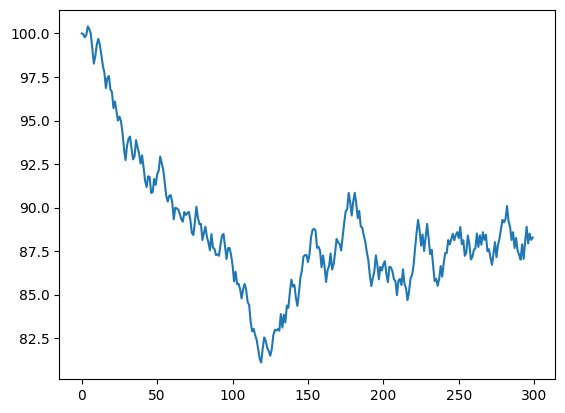

In [25]:
import matplotlib.pyplot as plt

model_data = mod.datacollector.get_model_vars_dataframe()
# Access the 'piyasa Fiyatı geçmisi' column and plot it directly
plt.plot(model_data['piyasa Fiyatı geçmisi'].iloc[0]) # .iloc[0] to access the first list in the column
plt.show()

In [26]:
# Model seviyesindeki verileri DataFrame olarak al
model_df = mod.datacollector.get_model_vars_dataframe()

# DataFrame'i görüntüle
#print(model_df)  #


# Agent seviyesindeki verileri DataFrame olarak al
agent_df = mod.datacollector.get_agent_vars_dataframe()

#DataFrame'i görüntüle
print(agent_df)  #

             TemelStrateji Teknik1Strateji ZıtlıkStratejisi
Step AgentID                                               
1    1                None            bear             None
     2                None            bear             None
     3                None            bear             None
     4                None            bear             None
     5                None            bear             None
     6                bear            None             None
     7                bear            None             None
     8                bear            None             None
     9                bear            None             None
     10               bear            None             None
     11               None            None             None
     12               None            None             None
     13               None            None             None
     14               None            None             None
     15               None            No

In [27]:
"""import matplotlib.pyplot as plt

model_data = mod.datacollector.get_model_vars_dataframe()
model_data.plot()
plt.show()"""

'import matplotlib.pyplot as plt\n\nmodel_data = mod.datacollector.get_model_vars_dataframe()\nmodel_data.plot()\nplt.show()'

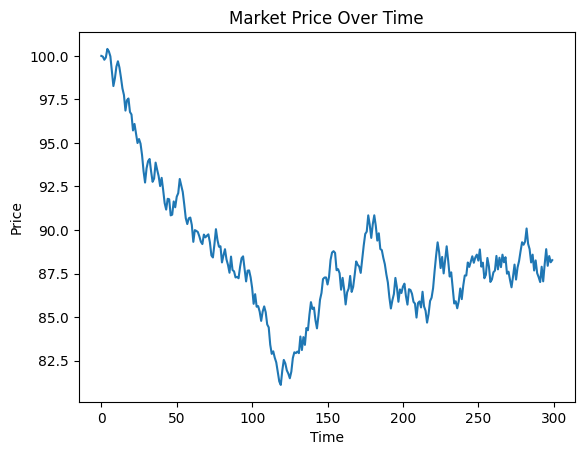

In [28]:
import matplotlib.pyplot as plt

model_data = mod.datacollector.get_model_vars_dataframe()
# Access the 'piyasa Fiyatı geçmisi' column and plot it directly
plt.plot(model_data['piyasa Fiyatı geçmisi'].iloc[0]) # .iloc[0] to access the first list in the column
plt.xlabel("Time")  # Add an x-axis label
plt.ylabel("Price")  # Add a y-axis label
plt.title("Market Price Over Time")  # Add a title to the plot
plt.show()